# Yield Prediction Training v2 (Phase 4)

**Improvements over v1:**
- Monthly climate aggregation (360 samples vs 60)
- Real disease severity from Phase 3 multitask model
- 5-fold cross-validation with confidence intervals
- Both yearly and monthly comparison

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.models.yield_model import (
    build_yield_dataset, build_yield_dataset_monthly, prepare_Xy,
    build_lstm_sequences, train_rf_baseline, optuna_xgboost, train_lstm,
    ensemble_predict, optuna_ensemble_weights, evaluate_metrics,
    kfold_evaluate
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Monthly Dataset (360 samples)

In [2]:
DAILY_CSV = 'data/raw/climate_daily_2015_2024.csv'
YIELD_CSV = 'data/raw/nhb_yield_mock_2015_2024.csv'

df_monthly = build_yield_dataset_monthly(DAILY_CSV, YIELD_CSV)
print(f"Monthly dataset: {df_monthly.shape}")
print(f"Columns: {df_monthly.columns.tolist()}")

X_m, y_m, feat_cols_m = prepare_Xy(df_monthly)
print(f"\nFeatures ({len(feat_cols_m)}): {feat_cols_m}")
print(f"X: {X_m.shape}, y: {y_m.shape}")

Monthly dataset: (720, 22)
Columns: ['year', 'region', 'variety', 'yield_t_ha', 'month', 'rain_mean', 'rain_cumul', 'rain_max', 'rain_days', 'tmax_mean', 'tmax_max', 'tmin_mean', 'tmin_min', 'temp_delta_mean', 'temp_var', 'humidity_mean', 'humidity_min', 'vpd_mean', 'vpd_max', 'disease_severity', 'var_Banganapalli', 'var_Raspuri']

Features (18): ['month', 'rain_mean', 'rain_cumul', 'rain_max', 'rain_days', 'tmax_mean', 'tmax_max', 'tmin_mean', 'tmin_min', 'temp_delta_mean', 'temp_var', 'humidity_mean', 'humidity_min', 'vpd_mean', 'vpd_max', 'disease_severity', 'var_Banganapalli', 'var_Raspuri']
X: (720, 18), y: (720,)


## 2. K-Fold Cross-Validation (Monthly Data)

In [3]:
# RF baseline with K-fold
def make_rf(X_train, y_train):
    m = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    m.fit(X_train, y_train)
    return m

rf_kfold = kfold_evaluate(X_m, y_m, make_rf, n_splits=5)
print("RF (5-fold):", {k: f"{v:.4f}" for k, v in rf_kfold.items()})

RF (5-fold): {'MAE_mean': '0.7159', 'MAE_std': '0.0243', 'RMSE_mean': '0.8800', 'RMSE_std': '0.0289', 'R2_mean': '0.4130', 'R2_std': '0.0759', 'NMAE%_mean': '9.7597', 'NMAE%_std': '0.2213'}


In [4]:
# XGBoost with K-fold
def make_xgb(X_train, y_train):
    m = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
    m.fit(X_train, y_train, verbose=False)
    return m

xgb_kfold = kfold_evaluate(X_m, y_m, make_xgb, n_splits=5)
print("XGBoost (5-fold):", {k: f"{v:.4f}" for k, v in xgb_kfold.items()})

XGBoost (5-fold): {'MAE_mean': '0.6270', 'MAE_std': '0.0276', 'RMSE_mean': '0.7895', 'RMSE_std': '0.0390', 'R2_mean': '0.5251', 'R2_std': '0.0816', 'NMAE%_mean': '8.5475', 'NMAE%_std': '0.3189'}


## 3. Optuna-Tuned XGBoost on Monthly Data

In [5]:
# Time-based split
train_mask = df_monthly['year'] <= 2021
test_mask = df_monthly['year'] > 2021

X_train, X_test = X_m[train_mask], X_m[test_mask]
y_train, y_test = y_m[train_mask], y_m[test_mask]

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (403, 18), Val: (101, 18), Test: (216, 18)


In [6]:
xgb_model, xgb_best_params = optuna_xgboost(X_tr_s, y_tr, X_val_s, y_val, n_trials=100)
xgb_preds = xgb_model.predict(X_test_s)
xgb_optuna_metrics = evaluate_metrics(y_test, xgb_preds)
print("XGBoost (Optuna, monthly):", xgb_optuna_metrics)
print("Best params:", xgb_best_params)

XGBoost (Optuna, monthly): {'MAE': 0.6508381962776184, 'RMSE': 0.8268266252249302, 'R2': 0.32856881618499756, 'NMAE%': 8.924421310424805}
Best params: {'max_depth': 3, 'learning_rate': 0.18254409860227802, 'n_estimators': 290, 'subsample': 0.9913186740532701, 'colsample_bytree': 0.8822015949411057, 'reg_alpha': 0.16385593189442957, 'reg_lambda': 0.0001761508935436928}


## 4. RF Baseline on Monthly Data

In [7]:
rf_model, rf_metrics = train_rf_baseline(X_tr_s, y_tr, X_test_s, y_test)
print("RF (monthly):", rf_metrics)

RF (monthly): {'MAE': 0.5482077544525595, 'RMSE': 0.7003712101835506, 'R2': 0.518241714083139, 'NMAE%': 7.517132759094238}


## 5. LSTM on Monthly Data

In [8]:
# LSTM uses yearly sequences (one per yield row = 60 rows)
sequences, seq_targets = build_lstm_sequences(DAILY_CSV, YIELD_CSV, seq_len=30)

# Build yearly yield df for time mask
df_yearly = pd.read_csv(YIELD_CSV)
lstm_train_mask = (df_yearly['year'] <= 2021).values
lstm_test_mask = (df_yearly['year'] > 2021).values

seq_train = sequences[lstm_train_mask]
seq_test = sequences[lstm_test_mask]
y_seq_train = seq_targets[lstm_train_mask]
y_seq_test = seq_targets[lstm_test_mask]

idx = int(len(seq_train) * 0.8)
seq_tr, seq_val = seq_train[:idx], seq_train[idx:]
y_seq_tr, y_seq_val = y_seq_train[:idx], y_seq_train[idx:]

lstm_model = train_lstm(seq_tr, y_seq_tr, seq_val, y_seq_val, epochs=300)

lstm_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(torch.tensor(seq_test)).numpy()
lstm_metrics = evaluate_metrics(y_seq_test, lstm_preds)
print("LSTM:", lstm_metrics)

LSTM: {'MAE': 0.8010478019714355, 'RMSE': 1.0142610047053437, 'R2': -0.010350584983825684, 'NMAE%': 10.984126091003418}


## 6. Ensemble

In [9]:
# Match lengths for ensemble
min_len = min(len(xgb_preds), len(lstm_preds))
xgb_ens = xgb_preds[:min_len]
lstm_ens = lstm_preds[:min_len]
y_ens = y_test[:min_len]

w_xgb = optuna_ensemble_weights(xgb_ens, lstm_ens, y_ens, n_trials=50)
ens_preds = ensemble_predict(xgb_ens, lstm_ens, w_xgb)
ens_metrics = evaluate_metrics(y_ens, ens_preds)
print(f"Ensemble (w_xgb={w_xgb:.2f}):", ens_metrics)

Ensemble (w_xgb=0.17): {'MAE': 0.8118148446083069, 'RMSE': 1.333777572218134, 'R2': -0.2808537483215332, 'NMAE%': 9.90823745727539}


## 7. Final Comparison

In [10]:
all_results = {
    'RF (monthly)': rf_metrics,
    'XGBoost Optuna (monthly)': xgb_optuna_metrics,
    'LSTM': lstm_metrics,
    f'Ensemble (w={w_xgb:.2f})': ens_metrics,
}

# Add K-fold results
all_results['RF 5-fold'] = {k.replace('_mean', ''): v for k, v in rf_kfold.items() if '_mean' in k}
all_results['XGB 5-fold'] = {k.replace('_mean', ''): v for k, v in xgb_kfold.items() if '_mean' in k}

results_df = pd.DataFrame(all_results).T
print("\n=== YIELD PREDICTION RESULTS ===")
print(results_df.to_string())

results_df.to_csv('models/yield_results_v2.csv')


=== YIELD PREDICTION RESULTS ===
                               MAE      RMSE        R2      NMAE%
RF (monthly)              0.548208  0.700371  0.518242   7.517133
XGBoost Optuna (monthly)  0.650838  0.826827  0.328569   8.924421
LSTM                      0.801048  1.014261 -0.010351  10.984126
Ensemble (w=0.17)         0.811815  1.333778 -0.280854   9.908237
RF 5-fold                 0.715934  0.879958  0.413023   9.759665
XGB 5-fold                0.626985  0.789526  0.525110   8.547499


Saved yield_comparison_v2.png


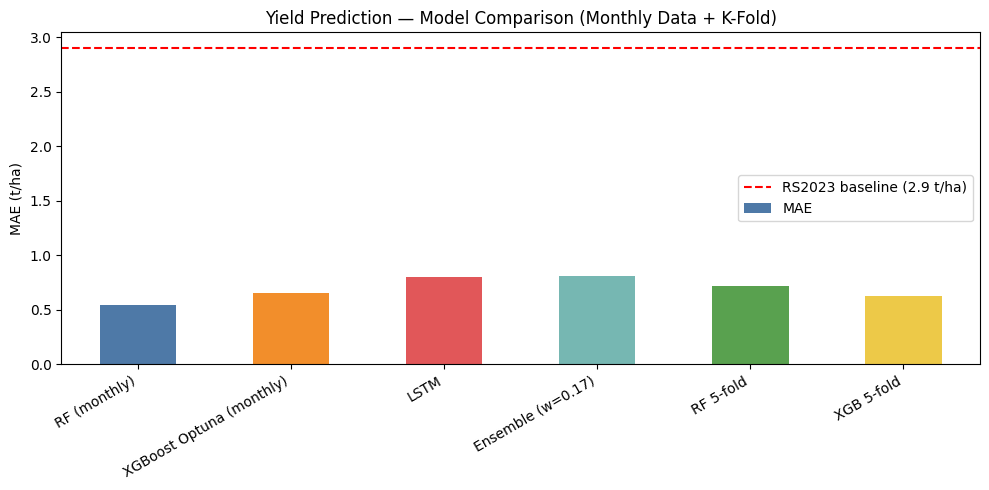

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df['MAE'].plot(kind='bar', ax=ax, color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948'])
ax.set_ylabel('MAE (t/ha)')
ax.set_title('Yield Prediction — Model Comparison (Monthly Data + K-Fold)')
ax.axhline(y=2.9, color='red', linestyle='--', label='RS2023 baseline (2.9 t/ha)')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/yield_comparison_v2.png')
print("Saved yield_comparison_v2.png")